# Fraud Detection â€“ Feature Reduction

This notebook performs the feature reduction stage of the pipeline.

It loads the preprocessed data from `data/processed/`, selects the most informative features using filter methods (correlation & mutual information), and optionally applies PCA for further dimensionality reduction.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Preprocessed Data

We use the files saved by the preprocessing notebook. These have already been cleaned, encoded, and scaled.

In [ ]:
# Load feature matrices and target vectors
X_train = pd.read_parquet("../data/processed/X_train.parquet")
X_test  = pd.read_parquet("../data/processed/X_test.parquet")
y_train = pd.read_parquet("../data/processed/y_train.parquet").values.ravel()
y_test  = pd.read_parquet("../data/processed/y_test.parquet").values.ravel()

# Load feature metadata for discrete feature handling
metadata = joblib.load("../data/processed/feature_metadata.pkl")
cat_cols = metadata.get('cat_cols', [])

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

## 2. Initial Feature Exploration & Cleaning

Before selection, we check for constant columns and highly correlated features to reduce redundancy.

In [3]:
# 2.1 Remove zero-variance features
variance_mask = X_train.var() > 0
constant_cols = X_train.columns[~variance_mask].tolist()
if constant_cols:
    print(f"Dropping {len(constant_cols)} constant columns.")
    X_train = X_train.loc[:, variance_mask]
    X_test  = X_test.loc[:, variance_mask]
else:
    print("No constant columns found.")

# 2.2 Remove highly correlated features
# We calculate correlation on a sample to save time
corr_matrix = X_train.sample(frac=0.1, random_state=RANDOM_STATE).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.98)]

if to_drop:
    print(f"Dropping {len(to_drop)} highly correlated features (> 0.95).")
    X_train.drop(columns=to_drop, inplace=True)
    X_test.drop(columns=to_drop, inplace=True)
else:
    print("No highly correlated features found.")

print("Shape after cleaning:", X_train.shape)

# Save the full feature set (after cleaning but before selection/PCA)
os.makedirs("../data/processed", exist_ok=True)
X_train.to_parquet("../data/processed/X_train_full.parquet", index=False)
X_test.to_parquet("../data/processed/X_test_full.parquet", index=False)
print("Full feature sets saved.")

No constant columns found.
Dropping 64 highly correlated features (> 0.95).
Shape after cleaning: (472432, 358)
Full feature sets saved.


## 3. Feature Selection using Mutual Information

Mutual information measures the dependency between each feature and the target, capturing nonâ€‘linear relationships as well.
Because the dataset is large, we compute MI on a **random sample** of the training data (e.g., 2%) to speed up the process.

In [5]:
# Sample for quick MI computation (use 5% of data for better stability)
sample_frac = 0.2
X_sample = X_train.sample(frac=sample_frac, random_state=RANDOM_STATE)
y_sample = y_train[X_sample.index]  # align target using index

# Identify discrete features for better MI estimation
discrete_mask = [col in cat_cols for col in X_train.columns]

# Calculate mutual information scores
print("Calculating Mutual Information scores...")
mi_scores = mutual_info_classif(X_sample, y_sample, discrete_features=discrete_mask, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# Display top 15
print("Top 15 features by Mutual Information:")
print(mi_series.head(15))
# Plot MI scores
plt.figure(figsize=(10, 6))
mi_series.head(20).plot(kind='barh', color='steelblue')
plt.title('Top 20 Features by Mutual Information Score')
plt.xlabel('Mutual Information Score')
plt.gca().invert_yaxis()
plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/mi_scores.png', dpi=150)
plt.show()


Calculating Mutual Information scores...
Top 15 features by Mutual Information:
card1                     0.022730
TransactionAmt_decimal    0.022187
V258                      0.021729
V257                      0.020127
V246                      0.020090
ProductCD                 0.019448
id_31                     0.019350
V201                      0.019132
TransactionAmt            0.019074
V200                      0.018417
TransactionAmt_log        0.018308
V199                      0.018055
C4                        0.017917
DeviceType                0.017621
V190                      0.017032
dtype: float64


## 4. Model-Based Feature Importance

In addition to filter-based Mutual Information, we use a tree-based model (Random Forest) to capture complex interactions and feature importance directly from a classifier.

In [6]:
# Use a slightly larger sample for Random Forest for better stability
X_sample_rf = X_train.sample(frac=0.1, random_state=RANDOM_STATE)
y_sample_rf = y_train[X_sample_rf.index]

rf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_sample_rf, y_sample_rf)

rf_series = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top 15 features by Random Forest Importance:")
print(rf_series.head(15))

Top 15 features by Random Forest Importance:
V258    0.035492
V246    0.032075
V201    0.029228
V257    0.028378
V189    0.025762
V244    0.024450
V243    0.023436
V45     0.021681
C1      0.021585
V200    0.021230
C7      0.019584
C4      0.017648
V259    0.017124
V199    0.017101
V187    0.017083
dtype: float64


## 5. Feature Understanding & Selection Optimization

We combine both rankings to identify the most robust features that perform well across both statistical (MI) and model-based (RF) methods.

Top 15 features by Combined Ranking:
V258     0.977988
V246     0.893798
V257     0.842528
V201     0.832615
V244     0.709562
V200     0.704210
V189     0.703734
V243     0.697509
V45      0.649632
C4       0.642751
V199     0.638084
C7       0.622854
V187     0.615171
V259     0.592184
card1    0.559034
Name: Combined_Score, dtype: float64


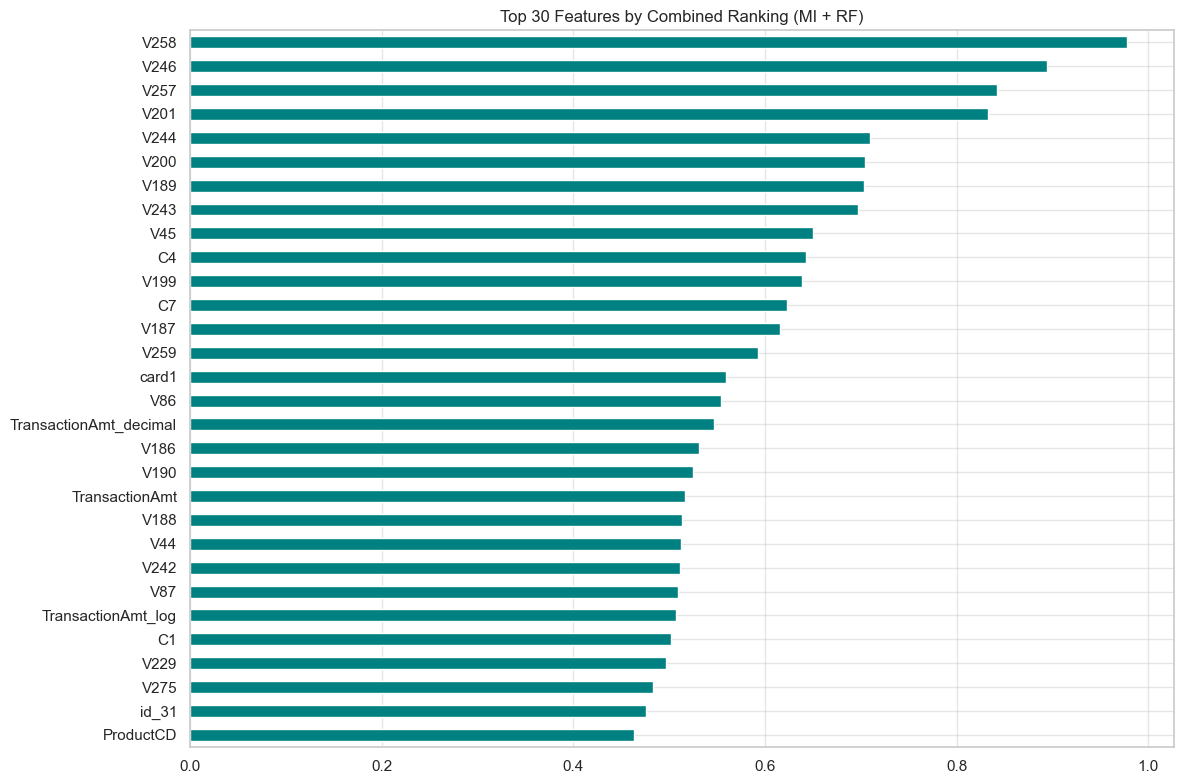

In [7]:
# Create a combined ranking
rankings = pd.DataFrame({
    'MI_Score': mi_series,
    'RF_Importance': rf_series
})

# Normalize scores for fair comparison
rankings['MI_Norm'] = rankings['MI_Score'] / rankings['MI_Score'].max()
rankings['RF_Norm'] = rankings['RF_Importance'] / rankings['RF_Importance'].max()

# Combined score (average)
rankings['Combined_Score'] = (rankings['MI_Norm'] + rankings['RF_Norm']) / 2
rankings = rankings.sort_values(by='Combined_Score', ascending=False)

print("Top 15 features by Combined Ranking:")
print(rankings['Combined_Score'].head(15))

# Visualise combined top features
plt.figure(figsize=(12, 8))
rankings['Combined_Score'].head(30).plot(kind='barh', color='teal')
plt.title('Top 30 Features by Combined Ranking (MI + RF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../results/figures/combined_importance.png")
plt.show()

## 6. Deep Understanding: Visualising Top Features

We visualize the distribution of the top-ranked features to understand how they differ between fraudulent and non-fraudulent transactions.

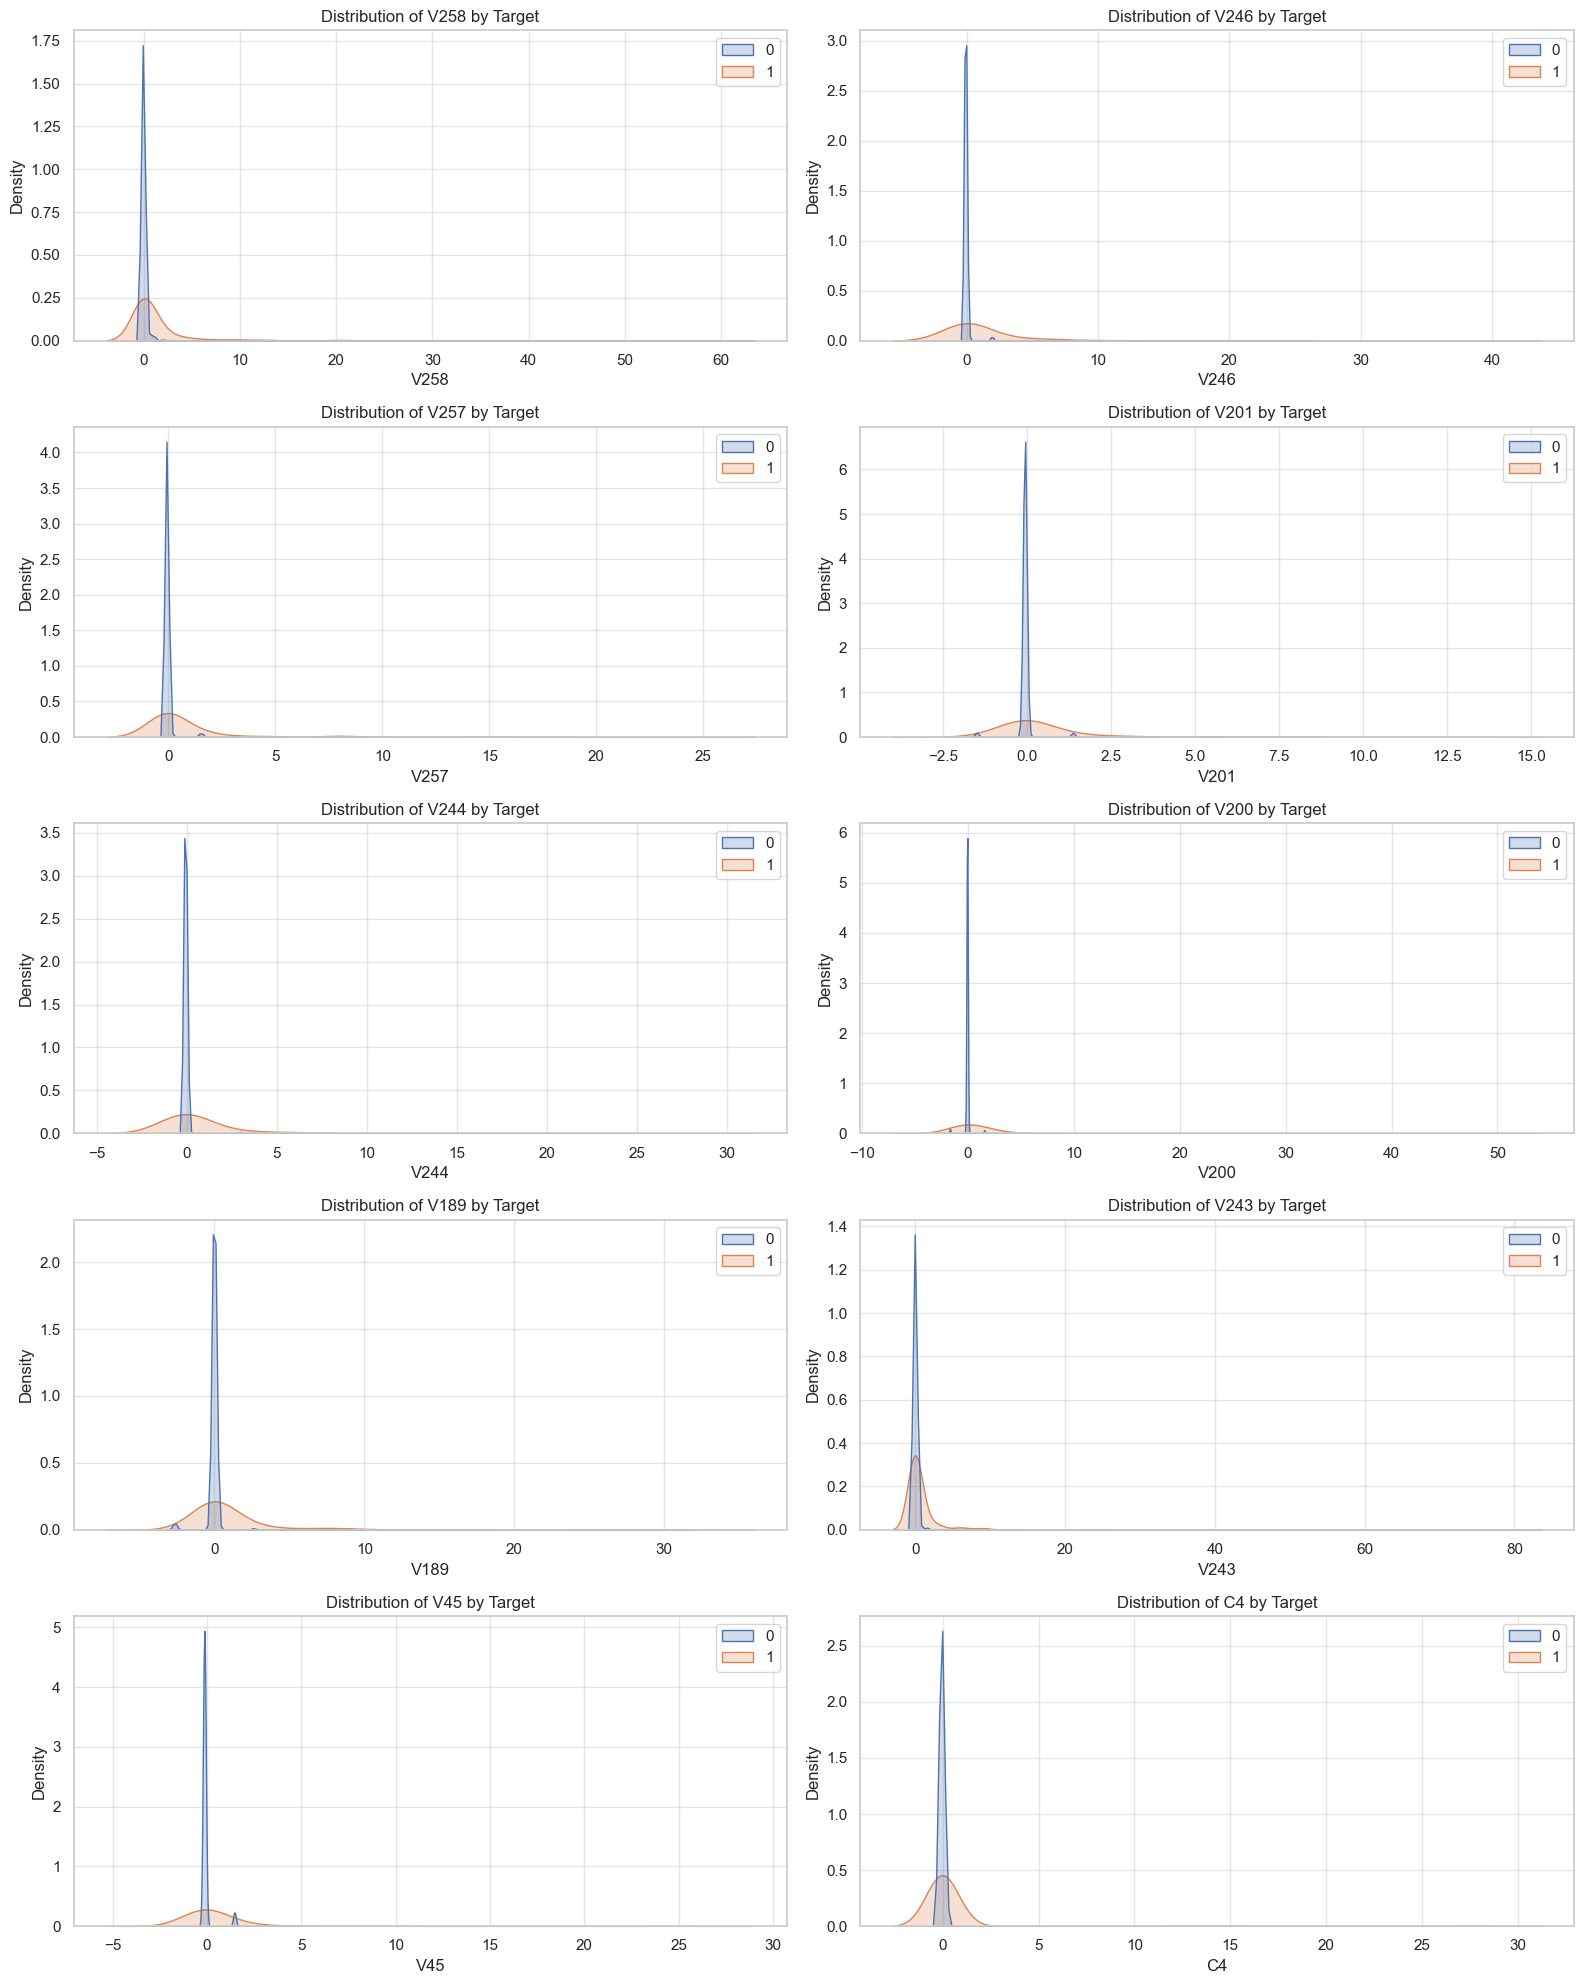

In [8]:
top_10_features = rankings.head(10).index.tolist()

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(top_10_features):
    sample_size = min(5000, len(X_train))
    X_plot_sample = X_train.sample(sample_size)
    sns.kdeplot(data=X_plot_sample, x=col, hue=y_train[X_plot_sample.index], 
                ax=axes[i], fill=True, common_norm=False)
    axes[i].set_title(f'Distribution of {col} by Target')

plt.tight_layout()
plt.savefig("../results/figures/top_features_distribution.png")
plt.show()

### Feature Correlation among Selected Features

We check for redundancy among the top features.

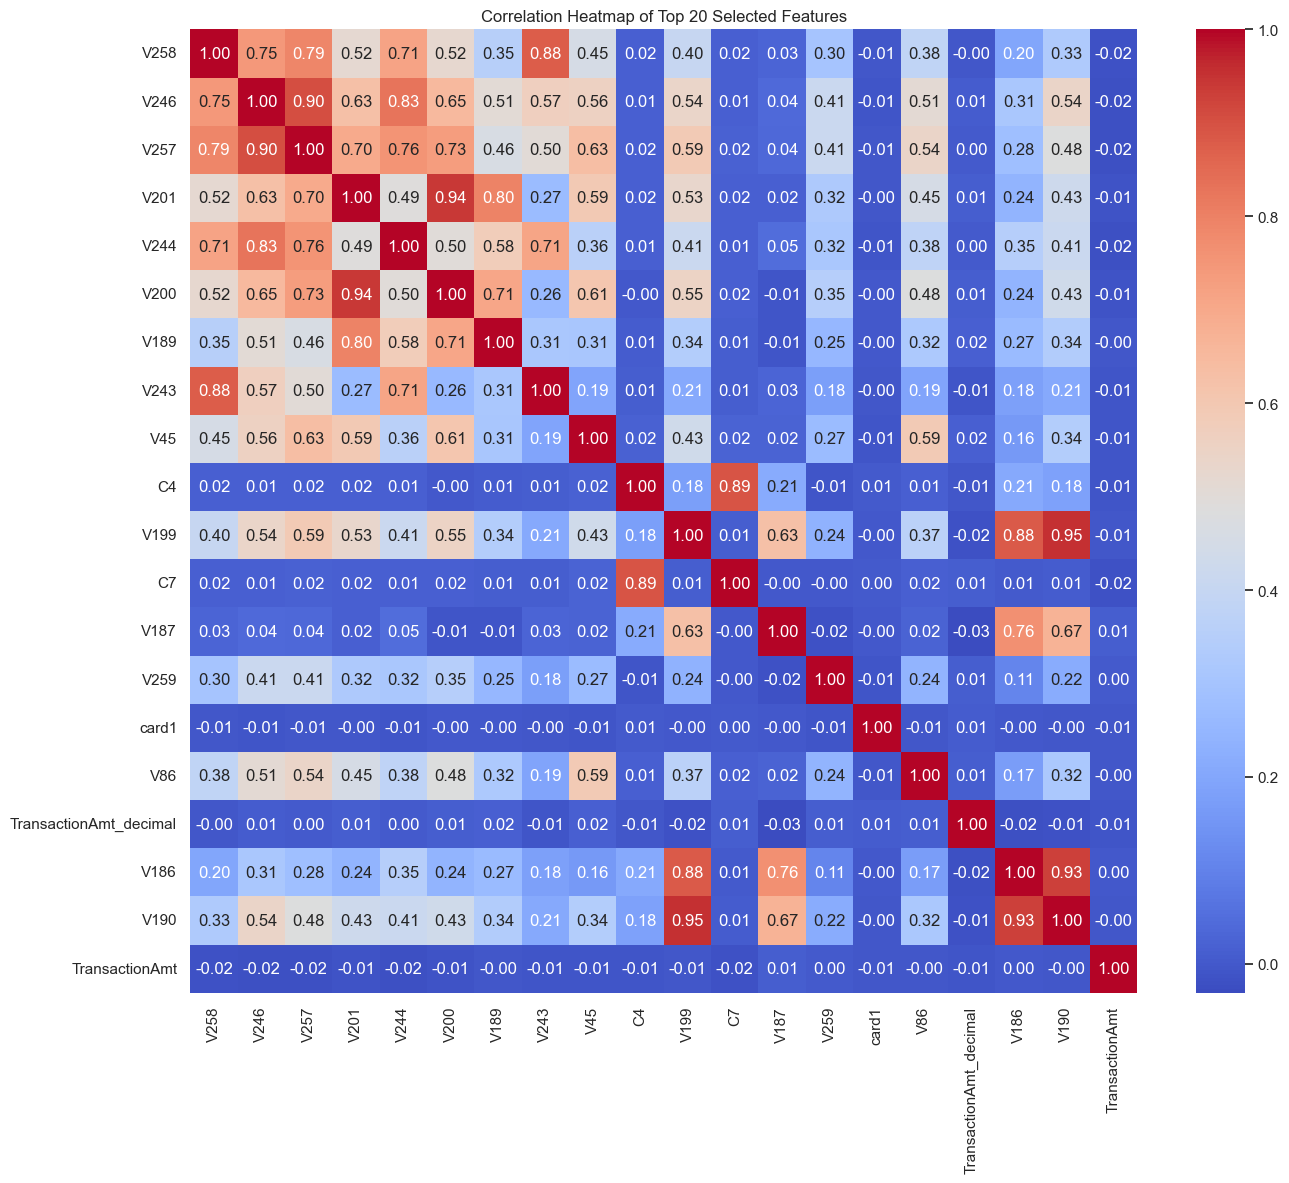

In [9]:
plt.figure(figsize=(14, 12))
top_20_features = rankings.head(20).index.tolist()
sns.heatmap(X_train[top_20_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Top 20 Selected Features')
plt.tight_layout()
plt.savefig("../results/figures/top_features_correlation.png")
plt.show()

## 7. Select Top *k* Features

To maximize model performance while maintaining efficiency, we use the top 50 selected features.

In [10]:
# Select top k features based on Combined Ranking
k = 50
selected_features = rankings.head(k).index.tolist()
print(f"Selected top {k} features based on Combined Ranking (MI + RF).")

# Reduce datasets to selected features
X_train_selected = X_train[selected_features]
X_test_selected  = X_test[selected_features]

print("Reduced training set shape:", X_train_selected.shape)
print("Reduced test set shape:", X_test_selected.shape)

Selected top 100 features based on Combined Ranking (MI + RF).
Reduced training set shape: (472432, 100)
Reduced test set shape: (118108, 100)


### Save list of selected features

In [11]:
# Save list of selected features for later use
os.makedirs("../data/processed", exist_ok=True)
pd.Series(selected_features).to_csv("../data/processed/selected_features.csv", index=False, header=False)
print("Selected features saved.")

Selected features saved.


## 8. Dimensionality Reduction with PCA

If we want to compress the feature space even further, we can apply PCA on the selected features. We will keep enough components to explain 95% of the variance.

In [12]:
# Scale the selected features (though they should already be scaled, it's safe to re-scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled  = scaler.transform(X_test_selected)

# Fit PCA on training data
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Original number of features:", X_train_selected.shape[1])
print("Number of PCA components (95% variance):", pca.n_components_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_)[-1])

Original number of features: 100
Number of PCA components (95% variance): 39
Cumulative explained variance: 0.9521580277956577


### Understanding PCA: Feature Loadings

We analyze which original features contribute most to the first few principal components.

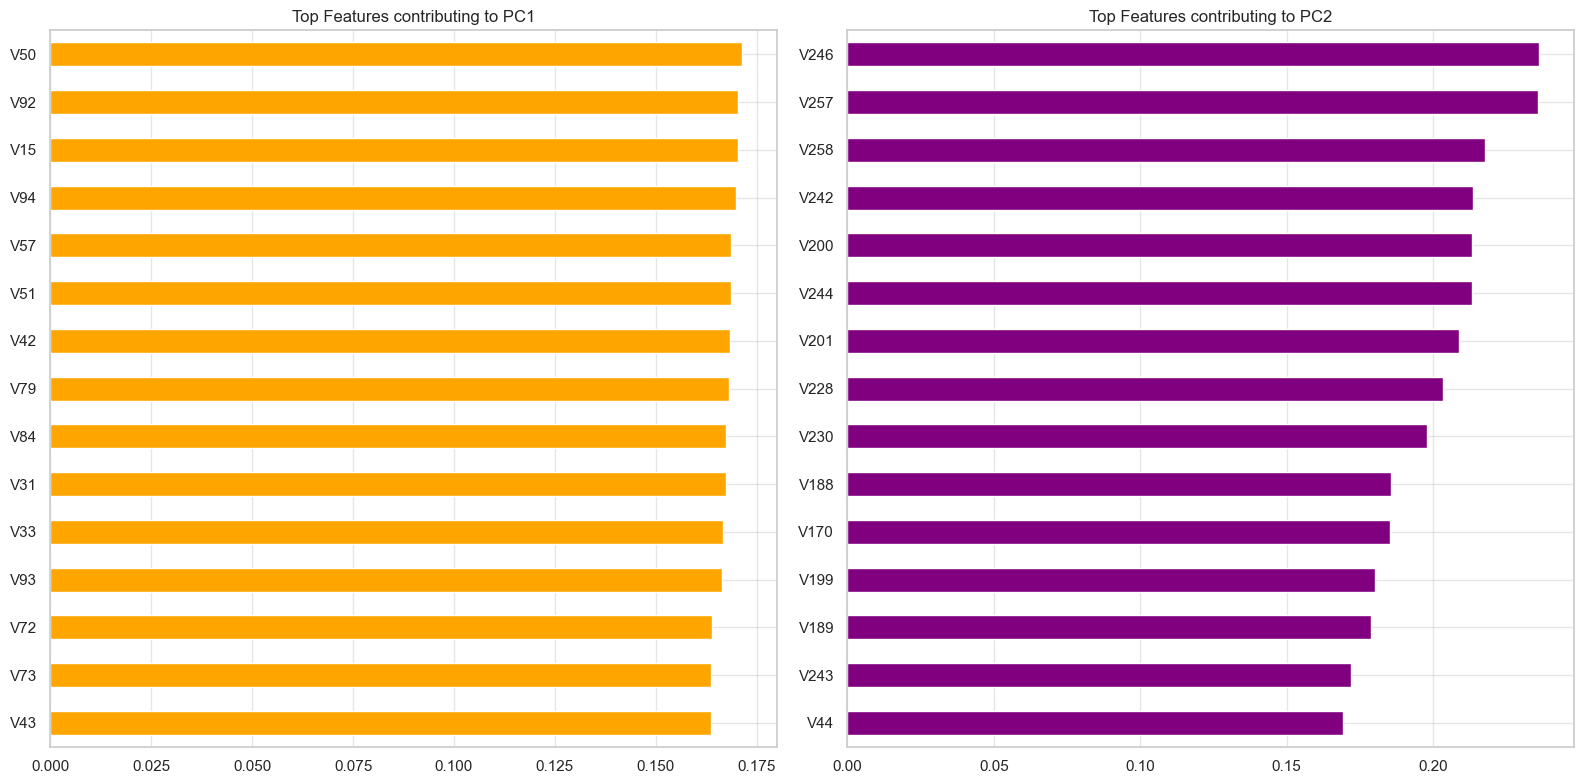

In [13]:
# Extract loadings
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=selected_features
)

# Plot loadings for PC1 and PC2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

loadings['PC1'].sort_values(ascending=False).head(15).plot(kind='barh', ax=ax1, color='orange')
ax1.set_title('Top Features contributing to PC1')
ax1.invert_yaxis()

loadings['PC2'].sort_values(ascending=False).head(15).plot(kind='barh', ax=ax2, color='purple')
ax2.set_title('Top Features contributing to PC2')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig("../results/figures/pca_loadings.png")
plt.show()

### Visualise PCA variance

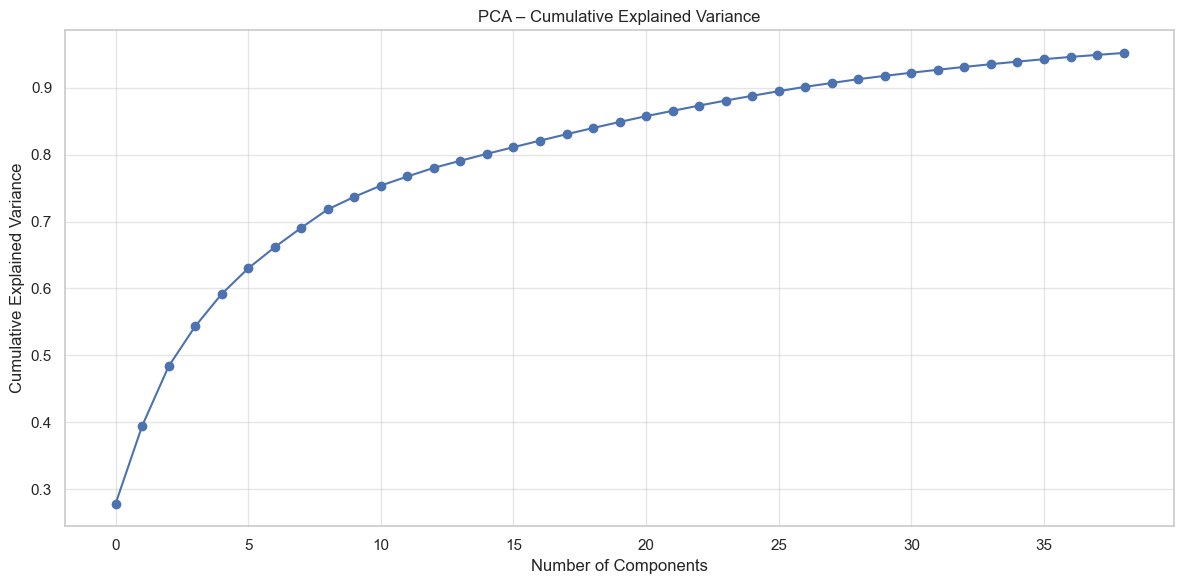

In [14]:
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA â€“ Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.savefig("../results/figures/pca_variance.png")
plt.show()

## 9. Save Final Reduced Data

We'll save both the selectedâ€‘features version and the PCA version so Memberâ€¯4 can choose which to use.
We also save the PCA object and the scaler used for PCA.

In [15]:
# Save the 'selected features' version
X_train_selected.to_parquet("../data/processed/X_train_selected.parquet", index=False)
X_train_selected.to_csv("../data/processed/X_train_selected.csv", index=False)
X_test_selected.to_parquet("../data/processed/X_test_selected.parquet", index=False)
X_test_selected.to_csv("../data/processed/X_test_selected.csv", index=False)

# Save the PCA version (convert to DataFrame for consistency)
pd.DataFrame(X_train_pca, columns=[f"PC{i+1}" for i in range(X_train_pca.shape[1])]).to_parquet("../data/processed/X_train_pca.parquet", index=False)
pd.DataFrame(X_train_pca, columns=[f"PC{i+1}" for i in range(X_train_pca.shape[1])]).to_csv("../data/processed/X_train_pca.csv", index=False)
pd.DataFrame(X_test_pca, columns=[f"PC{i+1}" for i in range(X_test_pca.shape[1])]).to_parquet("../data/processed/X_test_pca.parquet", index=False)
pd.DataFrame(X_test_pca, columns=[f"PC{i+1}" for i in range(X_test_pca.shape[1])]).to_csv("../data/processed/X_test_pca.csv", index=False)

# Save transformation objects
joblib.dump(pca, "../data/processed/pca.pkl")
joblib.dump(scaler, "../data/processed/pca_scaler.pkl")

print("All reduced datasets and objects saved!")

All reduced datasets and objects saved!


## Summary

- **Feature Exploration**: Dropped constant and highly redundant features.
- **Advanced Selection**: Implemented a consensus selection strategy combining **Mutual Information** (statistical) and **Random Forest** (model-based) rankings.
- **Optimization**: Used `discrete_features` in MI for more accurate information gain estimates of categorical variables.
- **Understanding**: Visualized top feature distributions and correlations to confirm predictive power and reduce redundancy.
- **PCA Analysis**: Performed PCA and analyzed feature loadings to understand the composition of principal components.
- **Export**: Saved reduced datasets (`_selected.csv`, `_pca.csv`) for model training.

**Next step:** The improved feature set will be used in `04_models.ipynb` for more robust model training.

*Note:* If the dataset is extremely large and the MI computation on a sample is still too heavy, consider using a smaller sample or using a parallelised joblib backend.